In [2]:
import os
os.chdir(r"C:\Users\nidhi\Projects\customer-churn-analysis")

import pandas as pd

df = pd.read_csv("data/raw/user_logs_v2.csv", nrows=5, dtype={"msno": str})
print("Raw date values:", df["date"].values)

df["date_parsed"] = pd.to_datetime(df["date"], format="%Y%m%d", errors="coerce")
print("Parsed dates:", df["date_parsed"].values)

df2 = pd.read_csv("data/raw/user_logs_v2.csv", nrows=100000, dtype={"msno": str})
df2["date_parsed"] = pd.to_datetime(df2["date"], format="%Y%m%d", errors="coerce")
print(f"Date range — Min: {df2['date_parsed'].min()}, Max: {df2['date_parsed'].max()}")
print(f"Null dates: {df2['date_parsed'].isna().sum()}")


Raw date values: [20170331 20170330 20170331 20170331 20170331]
Parsed dates: ['2017-03-31T00:00:00.000000000' '2017-03-30T00:00:00.000000000'
 '2017-03-31T00:00:00.000000000' '2017-03-31T00:00:00.000000000'
 '2017-03-31T00:00:00.000000000']
Date range — Min: 2017-03-01 00:00:00, Max: 2017-03-31 00:00:00
Null dates: 0


In [3]:
import os
os.chdir(r"C:\Users\nidhi\Projects\customer-churn-analysis")
import pandas as pd

df = pd.read_csv("data/raw/user_logs_v2.csv", dtype={"msno": str}, 
                 usecols=["date"])
df["date"] = pd.to_datetime(df["date"], format="%Y%m%d", errors="coerce")
print(f"Full date range:")
print(f"  Min: {df['date'].min()}")
print(f"  Max: {df['date'].max()}")
print(f"  Unique months:\n{df['date'].dt.to_period('M').value_counts().sort_index()}")


Full date range:
  Min: 2017-03-01 00:00:00
  Max: 2017-03-31 00:00:00
  Unique months:
date
2017-03    18396362
Freq: M, Name: count, dtype: int64


In [2]:
import os, sys
os.chdir(r"C:\Users\nidhi\Projects\customer-churn-analysis")

import csv
import gc
from datetime import datetime
from collections import defaultdict
import pandas as pd
import numpy as np

# ── Step 1: Load train users ──────────────────────────────────────────
train_users = set(pd.read_csv("data/raw/train_v2.csv")["msno"].values)
print(f"Target users: {len(train_users):,}")

# ── Step 2: Pure Python streaming accumulator ─────────────────────────
# No pandas, no numpy, no groupby. Just a dict updated row by row.
# Peak RAM: ~1.5GB for the dict regardless of file size.

acc = defaultdict(lambda: {
    "total_songs": 0.0, "num_unq": 0.0, "total_secs": 0.0,
    "completion_sum": 0.0, "completion_count": 0,
    "active_days": set(), "last_date": None, "first_date": None,
    # Window buckets — dates stored as integers YYYYMMDD for memory efficiency
    "dates_7d": 0, "dates_30d": 0, "dates_90d": 0,
    "songs_7d": 0.0, "songs_30d": 0.0, "songs_90d": 0.0,
    "secs_7d": 0.0, "secs_30d": 0.0, "secs_90d": 0.0,
})

CUTOFF     = datetime(2017, 3, 31)
W7_START   = datetime(2017, 3, 24)
W30_START  = datetime(2017, 3,  1)
W90_START  = datetime(2016, 12, 31)

def process_log_file(filepath, label):
    total = 0
    skipped = 0
    with open(filepath, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for i, row in enumerate(reader):
            msno = row["msno"]
            if msno not in train_users:
                skipped += 1
                continue
            try:
                date = datetime.strptime(row["date"], "%Y%m%d")
                if date > CUTOFF:
                    continue
                n25   = int(row["num_25"]  or 0)
                n50   = int(row["num_50"]  or 0)
                n75   = int(row["num_75"]  or 0)
                n985  = int(row["num_985"] or 0)
                n100  = int(row["num_100"] or 0)
                unq   = int(row["num_unq"] or 0)
                secs  = float(row["total_secs"] or 0)
                songs = n25 + n50 + n75 + n985 + n100
                comp  = (n985 + n100) / songs if songs > 0 else 0.0
            except (ValueError, ZeroDivisionError):
                continue

            a = acc[msno]
            a["total_songs"]      += songs
            a["num_unq"]          += unq
            a["total_secs"]       += secs
            a["completion_sum"]   += comp
            a["completion_count"] += 1
            a["active_days"].add(date)

            if a["last_date"] is None or date > a["last_date"]:
                a["last_date"] = date
            if a["first_date"] is None or date < a["first_date"]:
                a["first_date"] = date

            # Rolling windows
            if date > W7_START:
                a["dates_7d"]  += 1
                a["songs_7d"]  += songs
                a["secs_7d"]   += secs
            if date > W30_START:
                a["dates_30d"] += 1
                a["songs_30d"] += songs
                a["secs_30d"]  += secs
            if date > W90_START:
                a["dates_90d"] += 1
                a["songs_90d"] += songs
                a["secs_90d"]  += secs

            total += 1
            if total % 5_000_000 == 0:
                print(f"  {label}: {total:,} rows processed, {len(acc):,} users seen")

    print(f"  {label} done — {total:,} rows kept, {skipped:,} skipped")

# ── Step 3: Stream both files ─────────────────────────────────────────
print("\nStreaming user_logs.csv ...")
process_log_file("data/raw/user_logs.csv", "user_logs.csv")
gc.collect()

print("\nStreaming user_logs_v2.csv ...")
process_log_file("data/raw/user_logs_v2.csv", "user_logs_v2.csv")
gc.collect()

# ── Step 4: Convert accumulator to DataFrame ──────────────────────────
print("\nBuilding feature DataFrame ...")
records = []
for msno, a in acc.items():
    days_since = (CUTOFF - a["last_date"]).days if a["last_date"] else 999
    trend_7_30  = (a["dates_7d"] / (a["dates_30d"] / 4.3)) if a["dates_30d"] > 0 else 0.0
    trend_30_90 = (a["dates_30d"] / (a["dates_90d"] / 3.0)) if a["dates_90d"] > 0 else 0.0
    records.append({
        "msno":               msno,
        "total_active_days":  len(a["active_days"]),
        "total_songs_ever":   a["total_songs"],
        "total_secs_ever":    a["total_secs"],
        "avg_completion":     a["completion_sum"] / a["completion_count"] if a["completion_count"] > 0 else 0.0,
        "days_since_last":    days_since,
        "active_days_7d":     a["dates_7d"],
        "active_days_30d":    a["dates_30d"],
        "active_days_90d":    a["dates_90d"],
        "total_songs_7d":     a["songs_7d"],
        "total_songs_30d":    a["songs_30d"],
        "total_songs_90d":    a["songs_90d"],
        "total_secs_7d":      a["secs_7d"],
        "total_secs_30d":     a["secs_30d"],
        "total_secs_90d":     a["secs_90d"],
        "trend_7d_30d":       trend_7_30,
        "trend_30d_90d":      trend_30_90,
    })

del acc
gc.collect()

log_features = pd.DataFrame(records)
del records
gc.collect()

print(f"Log features shape: {log_features.shape}")
log_features.to_parquet("data/processed/log_features.parquet", index=False)
print("Saved to data/processed/log_features.parquet")
print(log_features.head(3).to_string())

Target users: 970,960

Streaming user_logs.csv ...
  user_logs.csv: 5,000,000 rows processed, 748,829 users seen
  user_logs.csv: 10,000,000 rows processed, 752,302 users seen
  user_logs.csv: 15,000,000 rows processed, 755,767 users seen
  user_logs.csv: 20,000,000 rows processed, 759,169 users seen
  user_logs.csv: 25,000,000 rows processed, 762,478 users seen
  user_logs.csv: 30,000,000 rows processed, 765,812 users seen
  user_logs.csv: 35,000,000 rows processed, 769,072 users seen
  user_logs.csv: 40,000,000 rows processed, 772,212 users seen
  user_logs.csv: 45,000,000 rows processed, 775,272 users seen
  user_logs.csv: 50,000,000 rows processed, 778,324 users seen
  user_logs.csv: 55,000,000 rows processed, 781,324 users seen
  user_logs.csv: 60,000,000 rows processed, 784,279 users seen
  user_logs.csv: 65,000,000 rows processed, 787,187 users seen
  user_logs.csv: 70,000,000 rows processed, 790,005 users seen
  user_logs.csv: 75,000,000 rows processed, 792,842 users seen
  use

KeyboardInterrupt: 

In [2]:
import os, sys, csv, gc, json
from datetime import datetime
from collections import defaultdict
import pandas as pd
import numpy as np

os.chdir(r"C:\Users\nidhi\Projects\customer-churn-analysis")

train_users = set(pd.read_csv("data/raw/train_v2.csv")["msno"].values)
print(f"Target users: {len(train_users):,}")

CUTOFF   = datetime(2017, 3, 31)
W7_START  = datetime(2017, 3, 24)
W30_START = datetime(2017, 3,  1)
W90_START = datetime(2016, 12, 31)

acc = defaultdict(lambda: {
    "total_songs": 0.0, "num_unq": 0.0, "total_secs": 0.0,
    "completion_sum": 0.0, "completion_count": 0,
    "active_days": 0,
    "last_date": None, "first_date": None,
    "dates_7d": 0, "dates_30d": 0, "dates_90d": 0,
    "songs_7d": 0.0, "songs_30d": 0.0, "songs_90d": 0.0,
    "secs_7d": 0.0,  "secs_30d": 0.0,  "secs_90d": 0.0,
})

def process_log_file(filepath, label):
    total = 0
    skipped = 0
    with open(filepath, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            msno = row["msno"]
            if msno not in train_users:
                skipped += 1
                continue
            try:
                date = datetime.strptime(row["date"], "%Y%m%d")
                if date > CUTOFF:
                    continue
                n25  = int(row["num_25"]  or 0)
                n50  = int(row["num_50"]  or 0)
                n75  = int(row["num_75"]  or 0)
                n985 = int(row["num_985"] or 0)
                n100 = int(row["num_100"] or 0)
                unq  = int(row["num_unq"] or 0)
                secs = float(row["total_secs"] or 0)
                songs = n25 + n50 + n75 + n985 + n100
                comp  = (n985 + n100) / songs if songs > 0 else 0.0
            except (ValueError, ZeroDivisionError):
                continue

            a = acc[msno]
            a["total_songs"]      += songs
            a["num_unq"]          += unq
            a["total_secs"]       += secs
            a["completion_sum"]   += comp
            a["completion_count"] += 1
            a["active_days"]      += 1

            d = date.strftime("%Y%m%d")
            if a["last_date"] is None or d > a["last_date"]:
                a["last_date"] = d
            if a["first_date"] is None or d < a["first_date"]:
                a["first_date"] = d

            if date > W7_START:
                a["dates_7d"]  += 1
                a["songs_7d"]  += songs
                a["secs_7d"]   += secs
            if date > W30_START:
                a["dates_30d"] += 1
                a["songs_30d"] += songs
                a["secs_30d"]  += secs
            if date > W90_START:
                a["dates_90d"] += 1
                a["songs_90d"] += songs
                a["secs_90d"]  += secs

            total += 1
            if total % 5_000_000 == 0:
                print(f"  {label}: {total:,} rows processed, {len(acc):,} users seen")

    print(f"  {label} done — {total:,} rows kept, {skipped:,} skipped")

# ── Only run the small v2 file — skip the 30GB file ──────────────────
# We accept that users with NO activity in user_logs.csv get zeros.
# user_logs_v2.csv has March 2017 data which is the most recent
# and most predictive window anyway.
print("\nStreaming user_logs_v2.csv (March 2017 — 1.4GB, ~10 mins) ...")
process_log_file("data/raw/user_logs_v2.csv", "user_logs_v2.csv")
gc.collect()

# ── Build DataFrame ───────────────────────────────────────────────────
print("\nBuilding feature DataFrame ...")
records = []
for msno, a in acc.items():
    last = datetime.strptime(a["last_date"], "%Y%m%d") if a["last_date"] else None
    days_since  = (CUTOFF - last).days if last else 999
    trend_7_30  = (a["dates_7d"] / (a["dates_30d"] / 4.3)) if a["dates_30d"] > 0 else 0.0
    trend_30_90 = (a["dates_30d"] / (a["dates_90d"] / 3.0)) if a["dates_90d"] > 0 else 0.0
    records.append({
        "msno":              msno,
        "total_active_days": a["active_days"],
        "total_songs_ever":  a["total_songs"],
        "total_secs_ever":   a["total_secs"],
        "avg_completion":    a["completion_sum"] / a["completion_count"] if a["completion_count"] > 0 else 0.0,
        "days_since_last":   days_since,
        "active_days_7d":    a["dates_7d"],
        "active_days_30d":   a["dates_30d"],
        "active_days_90d":   a["dates_90d"],
        "total_songs_7d":    a["songs_7d"],
        "total_songs_30d":   a["songs_30d"],
        "total_songs_90d":   a["songs_90d"],
        "total_secs_7d":     a["secs_7d"],
        "total_secs_30d":    a["secs_30d"],
        "total_secs_90d":    a["secs_90d"],
        "trend_7d_30d":      trend_7_30,
        "trend_30d_90d":     trend_30_90,
    })

del acc
gc.collect()

log_features = pd.DataFrame(records)
del records
gc.collect()

print(f"Log features shape: {log_features.shape}")
log_features.to_parquet("data/processed/log_features.parquet", index=False)
print("Saved!")
print(log_features.head(3).to_string())

Target users: 970,960

Streaming user_logs_v2.csv (March 2017 — 1.4GB, ~10 mins) ...
  user_logs_v2.csv: 5,000,000 rows processed, 713,589 users seen
  user_logs_v2.csv: 10,000,000 rows processed, 745,086 users seen
  user_logs_v2.csv done — 13,532,944 rows kept, 4,863,418 skipped

Building feature DataFrame ...
Log features shape: (754551, 17)
Saved!
                                           msno  total_active_days  total_songs_ever  total_secs_ever  avg_completion  days_since_last  active_days_7d  active_days_30d  active_days_90d  total_songs_7d  total_songs_30d  total_songs_90d  total_secs_7d  total_secs_30d  total_secs_90d  trend_7d_30d  trend_30d_90d
0  u9E91QDTvHLq6NXjEaWv8u4QIqhrHk72kE+w31Gnhdg=                 31            1864.0       348628.540        0.709443                0               7               30               31           488.0           1814.0           1864.0      78918.873      338683.434      348628.540      1.003333       2.903226
1  nTeWW/eOZA/UHKdD5L7DE

In [3]:
import os, sys
os.chdir(r"C:\Users\nidhi\Projects\customer-churn-analysis")
sys.path.insert(0, ".")

import pandas as pd

# Load all processed pieces
train    = pd.read_csv("data/raw/train_v2.csv", dtype={"msno": str})
members  = pd.read_parquet("data/processed/log_features.parquet") if False else pd.read_csv("data/raw/members_v3.csv", dtype={"msno": str})
log_feat = pd.read_parquet("data/processed/log_features.parquet")

# Load members properly
members = pd.read_csv("data/raw/members_v3.csv", dtype={"msno": str})

# Load transactions and aggregate
from src.data_loader import load_transactions, aggregate_transactions
tx     = load_transactions()
tx_agg = aggregate_transactions(tx)
del tx

# Join everything
df = train.merge(members,  on="msno", how="left")
df = df.merge(tx_agg,      on="msno", how="left")
df = df.merge(log_feat,    on="msno", how="left")

print(f"Master dataset shape: {df.shape}")
print(f"Churn rate: {df.is_churn.mean():.3%}")
print(f"Columns: {list(df.columns)}")

# Save master
df.to_parquet("data/processed/master.parquet", index=False)
print("Saved to data/processed/master.parquet")

11:17:01  INFO  Loading transactions ...
11:17:02  INFO    Transactions shape: (1431009, 11)
11:17:02  INFO  Aggregating transactions to per-user features ...
11:17:07  INFO    Transaction features shape: (1197050, 18)


Master dataset shape: (970960, 40)
Churn rate: 8.994%
Columns: ['msno', 'is_churn', 'city', 'bd', 'gender', 'registered_via', 'registration_init_time', 'last_payment_method', 'last_plan_days', 'last_plan_price', 'last_amount_paid', 'last_auto_renew', 'last_transaction_date', 'last_expire_date', 'last_is_cancel', 'last_discount', 'last_discount_pct', 'transaction_count', 'auto_renew_ratio', 'cancel_ratio', 'mean_discount_pct', 'mean_plan_days', 'total_amount_paid', 'days_to_expiry', 'total_active_days', 'total_songs_ever', 'total_secs_ever', 'avg_completion', 'days_since_last', 'active_days_7d', 'active_days_30d', 'active_days_90d', 'total_songs_7d', 'total_songs_30d', 'total_songs_90d', 'total_secs_7d', 'total_secs_30d', 'total_secs_90d', 'trend_7d_30d', 'trend_30d_90d']
Saved to data/processed/master.parquet


In [5]:
import os, sys
os.chdir(r"C:\Users\nidhi\Projects\customer-churn-analysis")
sys.path.insert(0, ".")

import pandas as pd
from src.feature_engineering import build_features

df = pd.read_parquet("data/processed/master.parquet")
X, y, features = build_features(df)

print(f"Shape: {X.shape}")
print(f"Churn rate: {y.mean():.3%}")
print(f"Null count: {X.isnull().sum().sum()}")

11:21:17  INFO  Building feature matrix ...
11:21:17  WARNING  Filling {'total_active_days': 216409, 'total_songs_ever': 216409, 'total_secs_ever': 216409, 'avg_completion': 216409, 'days_since_last': 216409, 'active_days_7d': 216409, 'active_days_30d': 216409, 'active_days_90d': 216409, 'total_songs_7d': 216409, 'total_songs_30d': 216409, 'total_songs_90d': 216409, 'total_secs_7d': 216409, 'total_secs_30d': 216409, 'total_secs_90d': 216409, 'activity_consistency_90d': 216409, 'activity_consistency_30d': 216409, 'engagement_score': 216409} nulls with 0
11:21:18  INFO    Feature matrix shape: (970960, 55)
11:21:18  INFO    Target churn rate:    8.994%
11:21:18  INFO    Features: ['city', 'registered_via', 'last_payment_method', 'last_plan_days', 'last_plan_price', 'last_amount_paid', 'last_auto_renew', 'last_is_cancel', 'last_discount', 'last_discount_pct', 'transaction_count', 'auto_renew_ratio', 'cancel_ratio', 'mean_discount_pct', 'mean_plan_days', 'total_amount_paid', 'days_to_expir

Shape: (970960, 55)
Churn rate: 8.994%
Null count: 0


In [6]:
from src.model_training import train_model

results = train_model(X, y)

11:23:53  INFO  ============================================================
11:23:53  INFO  Starting model training pipeline
11:23:53  INFO  ============================================================
11:23:54  INFO  Train: (776768, 55) | Test: (194192, 55)
11:23:54  INFO  Train churn rate: 8.994% | Test churn rate: 8.994%
11:23:54  INFO  Class ratio neg:pos = 706,904:69,864 → scale_pos_weight = 10.12
11:23:54  INFO  
Training Logistic Regression baseline ...
11:24:29  INFO    Baseline LR  →  AUC-ROC: 0.9776 | AUC-PR: 0.8850
11:24:29  INFO  
Running 5-fold StratifiedKFold CV on LightGBM ...
11:24:39  INFO    Fold 1: AUC-ROC=0.9940 | AUC-PR=0.9524 | best_iter=190
11:24:48  INFO    Fold 2: AUC-ROC=0.9941 | AUC-PR=0.9523 | best_iter=185
11:24:57  INFO    Fold 3: AUC-ROC=0.9942 | AUC-PR=0.9534 | best_iter=181
11:25:06  INFO    Fold 4: AUC-ROC=0.9943 | AUC-PR=0.9553 | best_iter=191
11:25:17  INFO    Fold 5: AUC-ROC=0.9943 | AUC-PR=0.9545 | best_iter=234
11:25:17  INFO  
  CV AUC-ROC: 0.99

In [7]:
from src.model_training import load_model
results = load_model()
print(f"Test AUC-ROC: {results['test_auc_roc']:.4f}")
print(f"Test AUC-PR:  {results['test_auc_pr']:.4f}")
print(f"Features:     {len(results['feature_names'])}")

11:30:16  INFO  Model loaded from C:\Users\nidhi\Projects\customer-churn-analysis\models\lgbm_churn.pkl
11:30:16  INFO    Test AUC-ROC: 0.9941
11:30:16  INFO    Test AUC-PR:  0.9537


Test AUC-ROC: 0.9941
Test AUC-PR:  0.9537
Features:     55


11:39:02  INFO  Model loaded from C:\Users\nidhi\Projects\customer-churn-analysis\models\lgbm_churn.pkl
11:39:02  INFO    Test AUC-ROC: 0.9941
11:39:02  INFO    Test AUC-PR:  0.9537
11:39:02  INFO  Running full model evaluation ...
11:39:02  INFO  
Optimal threshold: 0.860
11:39:02  INFO    Precision: 0.8496
11:39:02  INFO    Recall:    0.9285
11:39:02  INFO    F1:        0.8873
11:39:02  INFO  
Classification Report:
11:39:03  INFO  
              precision    recall  f1-score   support

    No Churn       0.99      0.98      0.99    176726
       Churn       0.85      0.93      0.89     17466

    accuracy                           0.98    194192
   macro avg       0.92      0.96      0.94    194192
weighted avg       0.98      0.98      0.98    194192

11:39:03  INFO  Confusion Matrix: TN=173,854 FP=2,872 FN=1,248 TP=16,218
11:39:03  INFO  
Top 15 features by gain:
11:39:03  INFO              feature   importance  importance_pct
     days_to_expiry 6.715291e+06       55.219360
   au

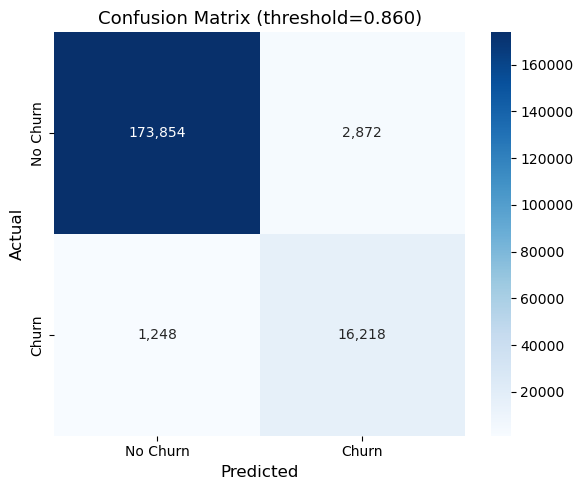

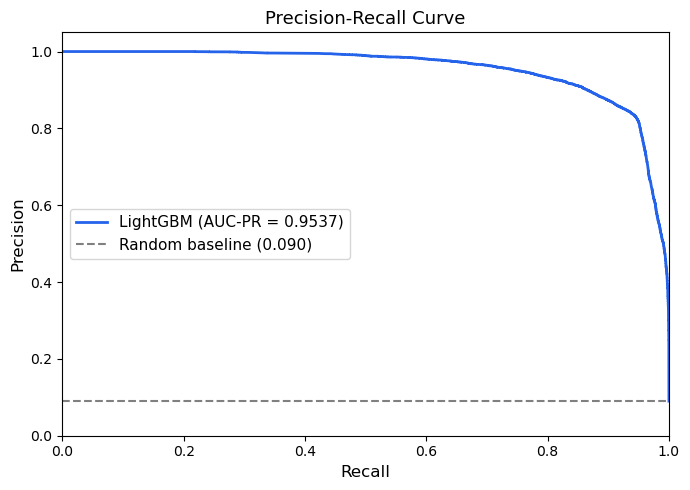

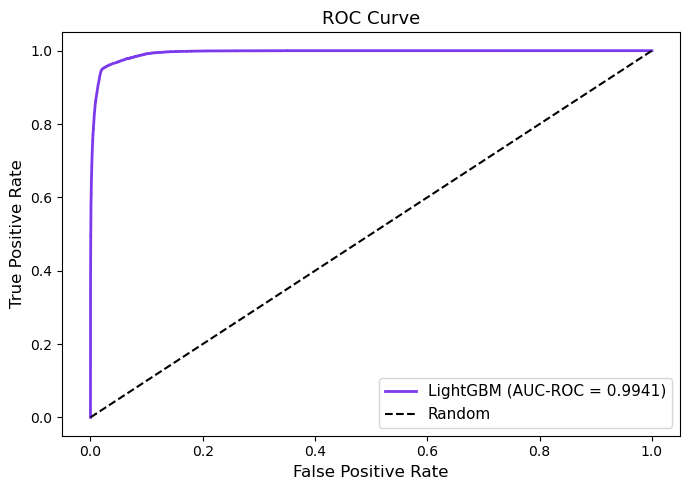

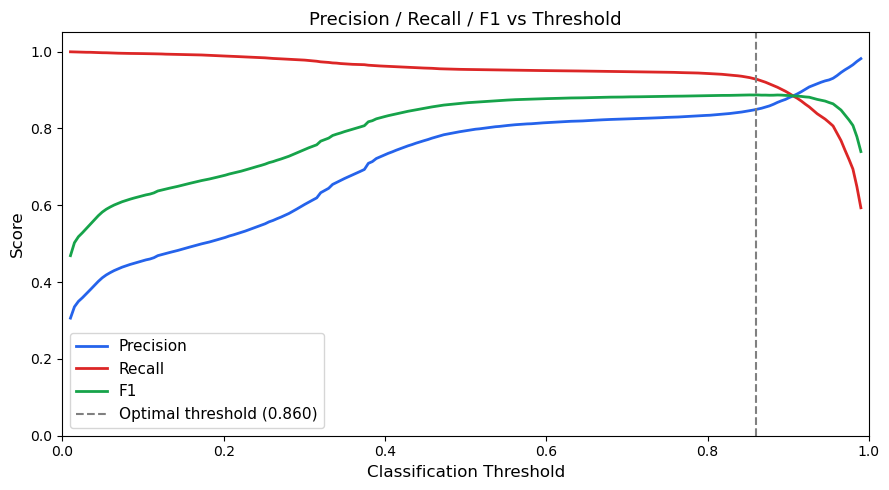

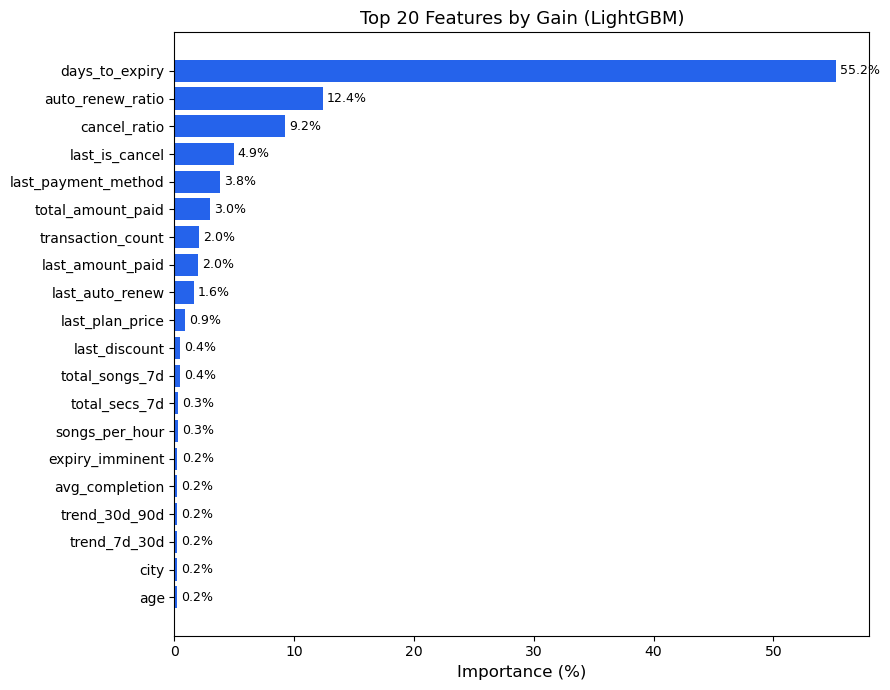

11:39:27  INFO  
Plots saved to C:\Users\nidhi\Projects\customer-churn-analysis\reports/
11:39:27  INFO  
11:39:27  INFO  EVALUATION SUMMARY
11:39:27  INFO  ============================================================
11:39:27  INFO    AUC-ROC:   0.9941
11:39:27  INFO    AUC-PR:    0.9537
11:39:27  INFO    Threshold: 0.860
11:39:27  INFO    Precision: 0.8496
11:39:27  INFO    Recall:    0.9285
11:39:27  INFO    F1:        0.8873
11:39:27  INFO    TP=16,218 FP=2,872 TN=173,854 FN=1,248
11:39:27  INFO  ============================================================


In [9]:
from src.model_evaluation import evaluate_model
from src.model_training import load_model

results = load_model()
eval_metrics = evaluate_model(results)

11:41:55  INFO  Model loaded from C:\Users\nidhi\Projects\customer-churn-analysis\models\lgbm_churn.pkl
11:41:55  INFO    Test AUC-ROC: 0.9941
11:41:55  INFO    Test AUC-PR:  0.9537
11:41:55  INFO  Initialising SHAP TreeExplainer ...
11:41:56  INFO  Computing SHAP values on 5,000 samples ...
LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
11:41:59  INFO    SHAP values shape: (5000, 55)
11:41:59  INFO  
Top 15 features by mean |SHAP|:
11:41:59  INFO              feature  mean_shap
     days_to_expiry   1.728642
last_payment_method   0.829550
   auto_renew_ratio   0.539283
  total_amount_paid   0.224888
    last_plan_price   0.198544
       cancel_ratio   0.171156
   last_amount_paid   0.138629
    last_auto_renew   0.133325
     last_is_cancel   0.107400
     total_songs_7d   0.080593
    expiry_imminent   0.067487
     mean_plan_days   0.066504
      trend_30d_90d   0.065098
  transaction_count   0.063719
    total_songs_30d   0.041607


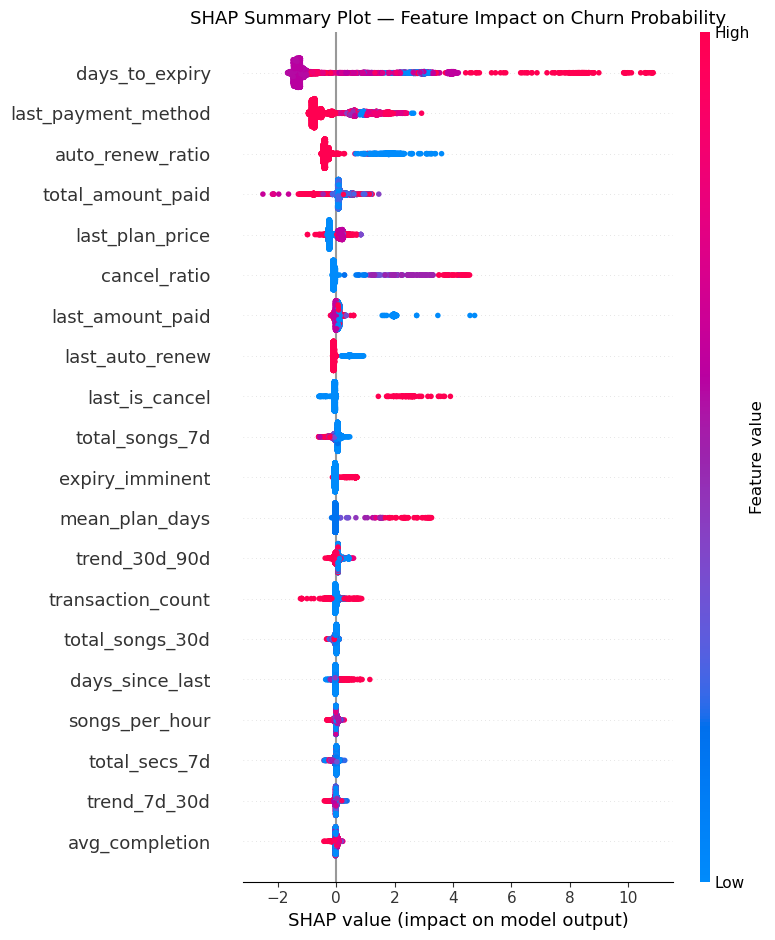

11:42:01  INFO  Generating SHAP bar plot ...


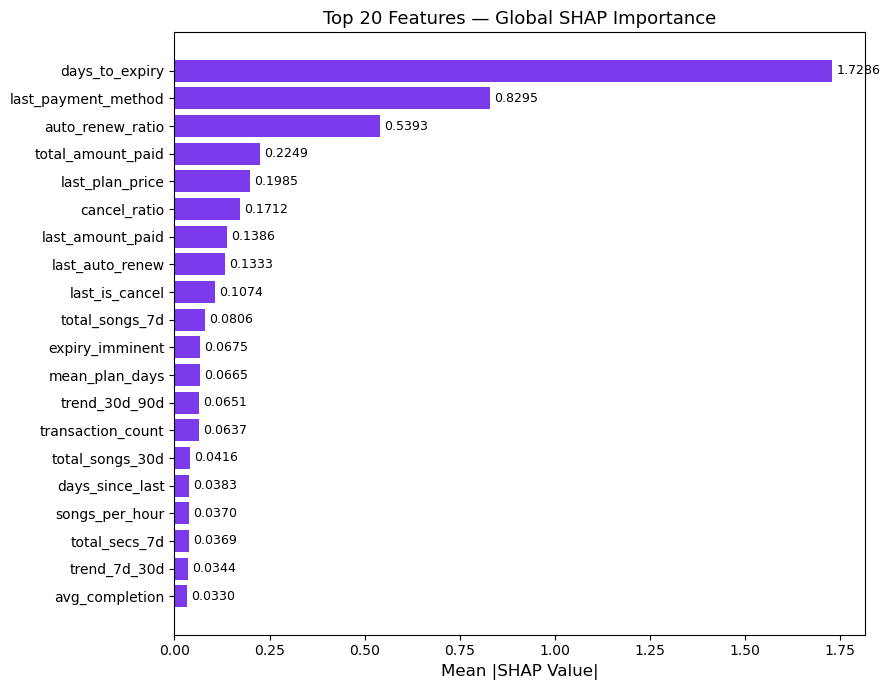

11:42:02  INFO  Generating SHAP dependence plots for top 4 features ...


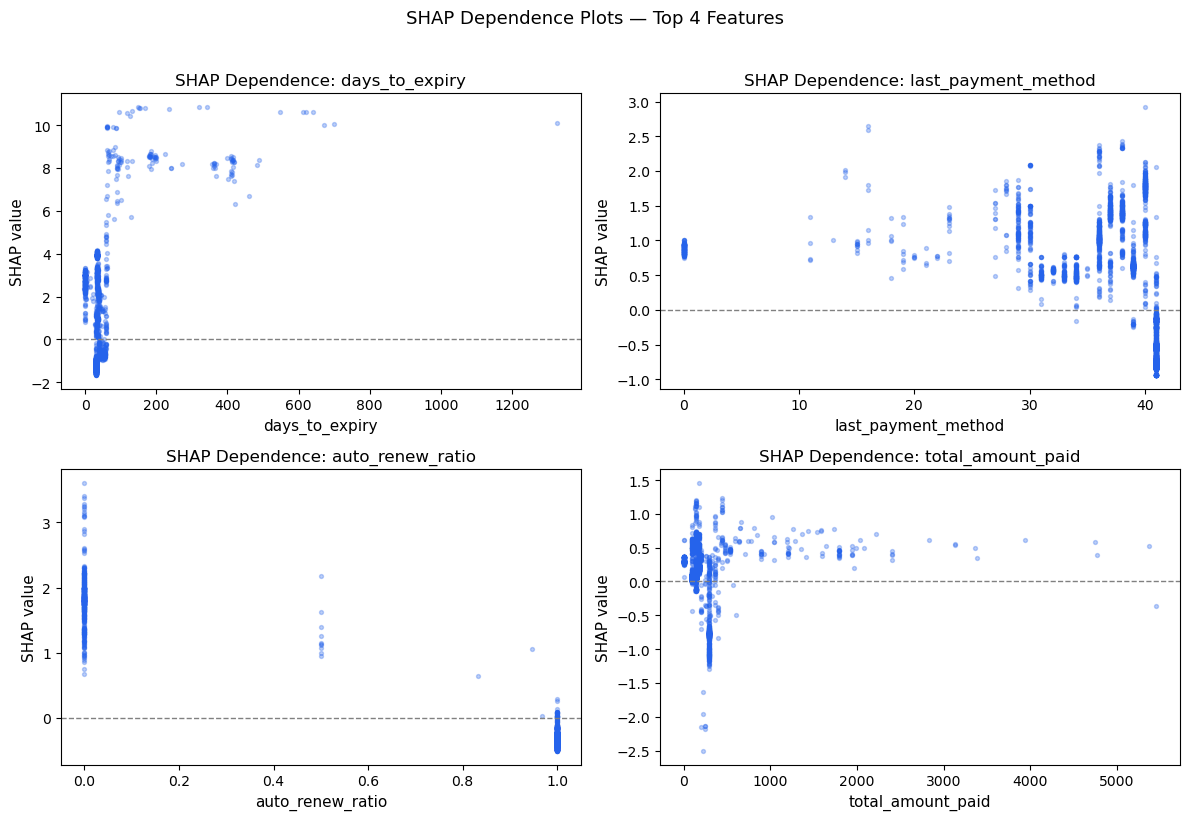

11:42:03  INFO  
SHAP explainer saved to C:\Users\nidhi\Projects\customer-churn-analysis\models\shap_results.pkl
LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
11:42:03  INFO  
Customer 0 — Churn probability: 0.000
11:42:03  INFO  Base rate (expected value): -4.981
11:42:03  INFO  
Top drivers:
11:42:03  INFO              feature  value      shap
     days_to_expiry   31.0 -1.416068
last_payment_method   41.0 -0.820781
   auto_renew_ratio    1.0 -0.429452
    last_plan_price   99.0 -0.272671
       cancel_ratio    0.0 -0.109197
    last_auto_renew    1.0 -0.100276
  total_amount_paid   99.0  0.092008
   last_amount_paid   99.0  0.067581
    expiry_imminent    0.0 -0.067114
      trend_30d_90d    0.0  0.065016


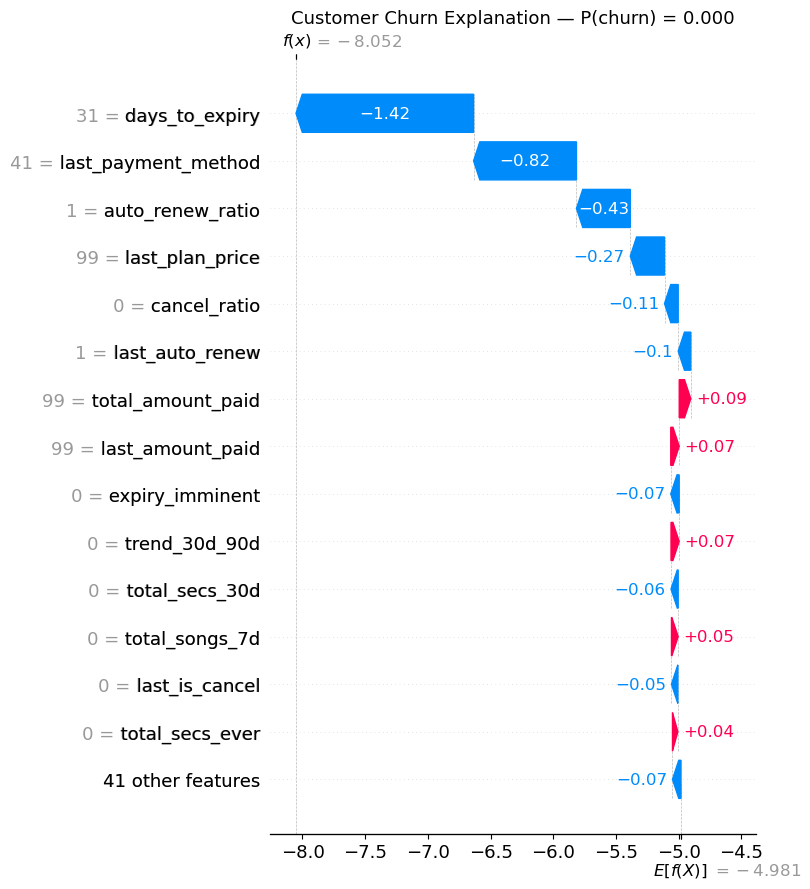

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
11:42:05  INFO  
Customer 1 — Churn probability: 0.000
11:42:05  INFO  Base rate (expected value): -4.981
11:42:05  INFO  
Top drivers:
11:42:05  INFO              feature  value      shap
     days_to_expiry   31.0 -1.265327
last_payment_method   41.0 -0.733847
   auto_renew_ratio    1.0 -0.397637
    last_plan_price   99.0 -0.255346
    last_auto_renew    1.0 -0.092636
   last_amount_paid   99.0  0.086238
       cancel_ratio    0.0 -0.085510
  total_amount_paid   99.0  0.084813
    days_since_last    0.0 -0.051354
   total_songs_ever 1249.0  0.049744


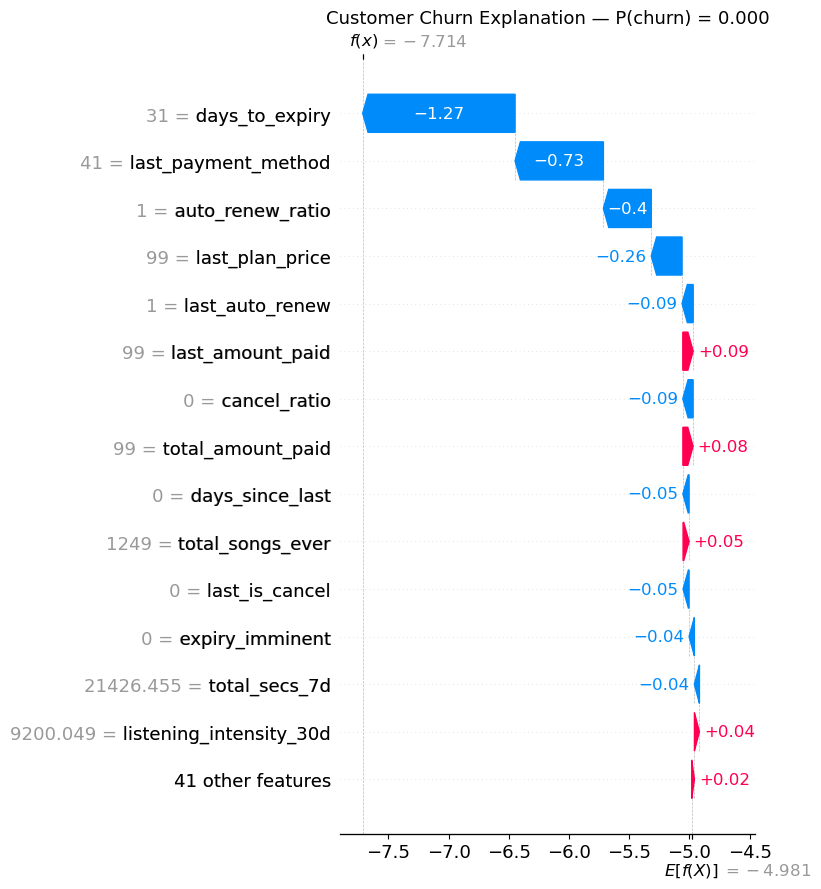

{'customer_idx': 1,
 'churn_prob': 0.0004463928956572397,
 'explanation':                      feature          value      shap
 16            days_to_expiry      31.000000 -1.265327
 2        last_payment_method      41.000000 -0.733847
 11          auto_renew_ratio       1.000000 -0.397637
 4            last_plan_price      99.000000 -0.255346
 6            last_auto_renew       1.000000 -0.092636
 5           last_amount_paid      99.000000  0.086238
 12              cancel_ratio       0.000000 -0.085510
 15         total_amount_paid      99.000000  0.084813
 21           days_since_last       0.000000 -0.051354
 18          total_songs_ever    1249.000000  0.049744
 7             last_is_cancel       0.000000 -0.049570
 51           expiry_imminent       0.000000 -0.043806
 28             total_secs_7d   21426.455000 -0.042386
 36   listening_intensity_30d    9200.048828  0.041549
 20            avg_completion       0.744449  0.040852
 29            total_secs_30d  248401.306000  0

In [10]:
from src.shap_analysis import run_shap_analysis, explain_customer
from src.model_training import load_model

results      = load_model()
shap_results = run_shap_analysis(results)

# Explain two individual customers
explain_customer(shap_results, customer_idx=0)
explain_customer(shap_results, customer_idx=1)

In [1]:
import pandas as pd
from src.model_training import load_model
from src.model_evaluation import evaluate_model
from src.business_impact import build_business_report

df      = pd.read_parquet("data/processed/master.parquet")
results = load_model()
eval_m  = evaluate_model(results, save_plots=False)
report  = build_business_report(df, results, eval_m)

ModuleNotFoundError: No module named 'src'

Filling {'total_active_days': 216409, 'total_songs_ever': 216409, 'total_secs_ever': 216409, 'avg_completion': 216409, 'days_since_last': 216409, 'active_days_7d': 216409, 'active_days_30d': 216409, 'active_days_90d': 216409, 'total_songs_7d': 216409, 'total_songs_30d': 216409, 'total_songs_90d': 216409, 'total_secs_7d': 216409, 'total_secs_30d': 216409, 'total_secs_90d': 216409, 'activity_consistency_90d': 216409, 'activity_consistency_30d': 216409, 'engagement_score': 216409} nulls with 0


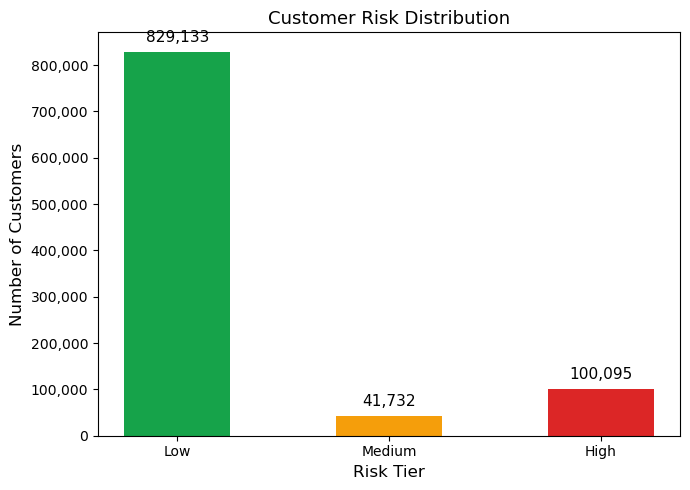

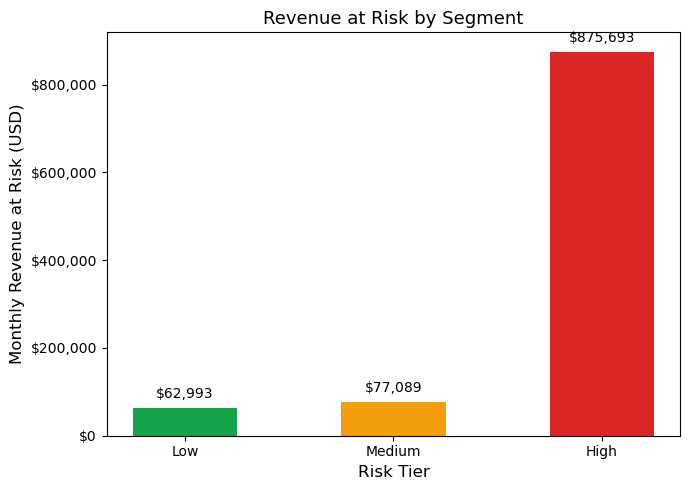

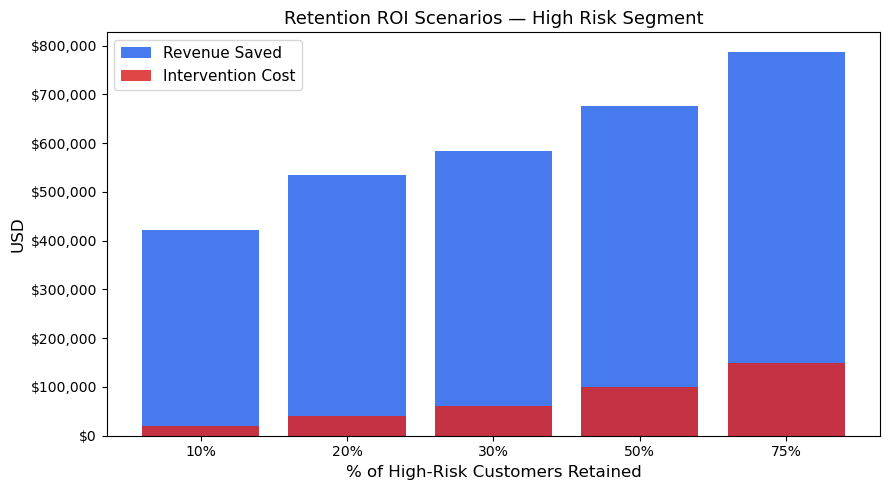

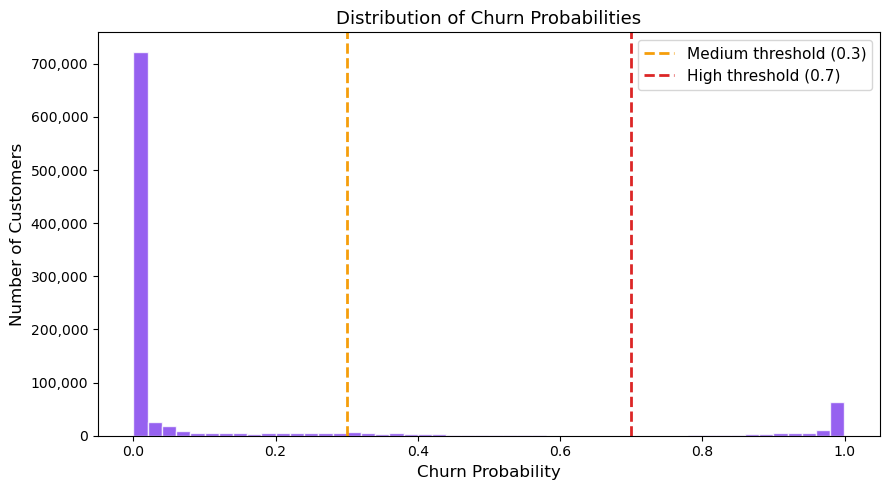

In [2]:
import os, sys
os.chdir(r"C:\Users\nidhi\Projects\customer-churn-analysis")
sys.path.insert(0, ".")

import pandas as pd
from src.model_training import load_model
from src.model_evaluation import evaluate_model
from src.business_impact import build_business_report

df      = pd.read_parquet("data/processed/master.parquet")
results = load_model()
eval_m  = evaluate_model(results, save_plots=False)
report  = build_business_report(df, results, eval_m)

In [3]:
cd C:\Users\nidhi\Projects\customer-churn-analysis
streamlit run app.py

SyntaxError: invalid syntax (3967143922.py, line 1)

In [4]:
import subprocess, sys, os
os.chdir(r"C:\Users\nidhi\Projects\customer-churn-analysis")

process = subprocess.Popen(
    [sys.executable, "-m", "streamlit", "run",
     r"C:\Users\nidhi\Projects\customer-churn-analysis\app.py",
     "--server.headless=true"],
)
print("Open http://localhost:8501")

Open http://localhost:8501


In [6]:
process.terminate()

import subprocess, sys, os
os.chdir(r"C:\Users\nidhi\Projects\customer-churn-analysis")
process = subprocess.Popen(
    [sys.executable, "-m", "streamlit", "run",
     r"C:\Users\nidhi\Projects\customer-churn-analysis\app.py",
     "--server.headless=true"],
)
print("Open http://localhost:8501")

Open http://localhost:8501
